In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/usgs/earthquake-database/database.csv


# Earthquake Clustering with DBSCAN
### Unsupervised Geospatial Analysis of Global Seismic Activity (1965–2016)

**Dataset:** USGS Significant Earthquakes | 23,412 records | 21 features  
**Goal:** Apply DBSCAN to discover tectonic plate boundary clusters from raw geospatial data — and demonstrate why K-Means fails on this problem.

---

## 📋 Table of Contents
1. Data Loading & Initial Inspection
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Scaling
5. DBSCAN — Epsilon Tuning (K-Distance Graph)
6. DBSCAN Clustering & World Map Visualization
7. K-Means Comparison
8. Cluster Evaluation (Silhouette Score)
9. Anomaly Analysis
10. Key Findings & Conclusion

---

## 1. Data Cleaning & Preprocessing
> Before any modeling, we inspect nulls, drop irrelevant columns, filter only earthquake events, and parse datetime.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv('/kaggle/input/datasets/organizations/usgs/earthquake-database/database.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (23412, 21)

Columns:
 ['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error', 'Depth Seismic Stations', 'Magnitude', 'Magnitude Type', 'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap', 'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID', 'Source', 'Location Source', 'Magnitude Source', 'Status']

First 5 rows:


,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [4]:
# Check null counts and data types
print("=== NULL VALUE SUMMARY ===")
print(df.isnull().sum())
print("\n=== DATA TYPES ===")
print(df.dtypes)
print("\n=== Unique Event Types ===")
print(df['Type'].value_counts())

=== NULL VALUE SUMMARY ===
Date                              0
Time                              0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source                            0
Location Source                   0
Magnitude Source                  0
Status                            0
dtype: int64

=== DATA TYPES ===
Date                           object
Time                           object
Latitude                      float64
Longitude                     float64
Type                           o

###  Cleaning Decisions:
- **Drop** high-null columns (>50% missing): `Depth Error`, `Depth Seismic Stations`, `Magnitude Error`, `Magnitude Seismic Stations`, `Azimuthal Gap`, `Horizontal Distance`, `Horizontal Error`, `Root Mean Square`
- **Drop** metadata columns not useful for clustering: `ID`, `Source`, `Location Source`, `Magnitude Source`, `Status`
- **Filter** only `Type == 'Earthquake'` — Nuclear Explosions and Explosions are man-made events, not seismic
- **Parse** `Date` + `Time` into a single datetime column and extract `Year`
- **Drop** 3 rows with null `Magnitude Type`

In [5]:
# Keep only Earthquakes
df = df[df['Type'] == 'Earthquake'].copy()
print(f"After type filter: {df.shape}")

# Drop high-null and irrelevant columns
drop_cols = [
    'Depth Error', 'Depth Seismic Stations', 'Magnitude Error',
    'Magnitude Seismic Stations', 'Azimuthal Gap', 'Horizontal Distance',
    'Horizontal Error', 'Root Mean Square', 'ID', 'Source',
    'Location Source', 'Magnitude Source', 'Status', 'Type'
]
df.drop(columns=drop_cols, inplace=True)

# Drop rows with null Magnitude Type
df.dropna(subset=['Magnitude Type'], inplace=True)

# Parse datetime and extract year
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df.dropna(subset=['DateTime'], inplace=True)
df['Year'] = df['DateTime'].dt.year
df.drop(columns=['Date', 'Time'], inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print(f"Final clean shape: {df.shape}")
print(f"\nRemaining columns: {df.columns.tolist()}")
print(f"\nNull check:\n{df.isnull().sum()}")
df.head()

After type filter: (23232, 21)
Final clean shape: (23226, 7)

Remaining columns: ['Latitude', 'Longitude', 'Depth', 'Magnitude', 'Magnitude Type', 'DateTime', 'Year']

Null check:
Latitude          0
Longitude         0
Depth             0
Magnitude         0
Magnitude Type    0
DateTime          0
Year              0
dtype: int64


,Latitude,Longitude,Depth,Magnitude,Magnitude Type,DateTime,Year
0,19.246,145.616,131.6,6.0,MW,1965-01-02 13:44:18,1965
1,1.863,127.352,80.0,5.8,MW,1965-01-04 11:29:49,1965
2,-20.579,-173.972,20.0,6.2,MW,1965-01-05 18:05:58,1965
3,-59.076,-23.557,15.0,5.8,MW,1965-01-08 18:49:43,1965
4,11.938,126.427,15.0,5.8,MW,1965-01-09 13:32:50,1965


## 2. Exploratory Data Analysis (EDA)
> Understanding the distribution of key features before clustering. We analyze magnitude distribution, depth categories, yearly trends, and geographic spread.

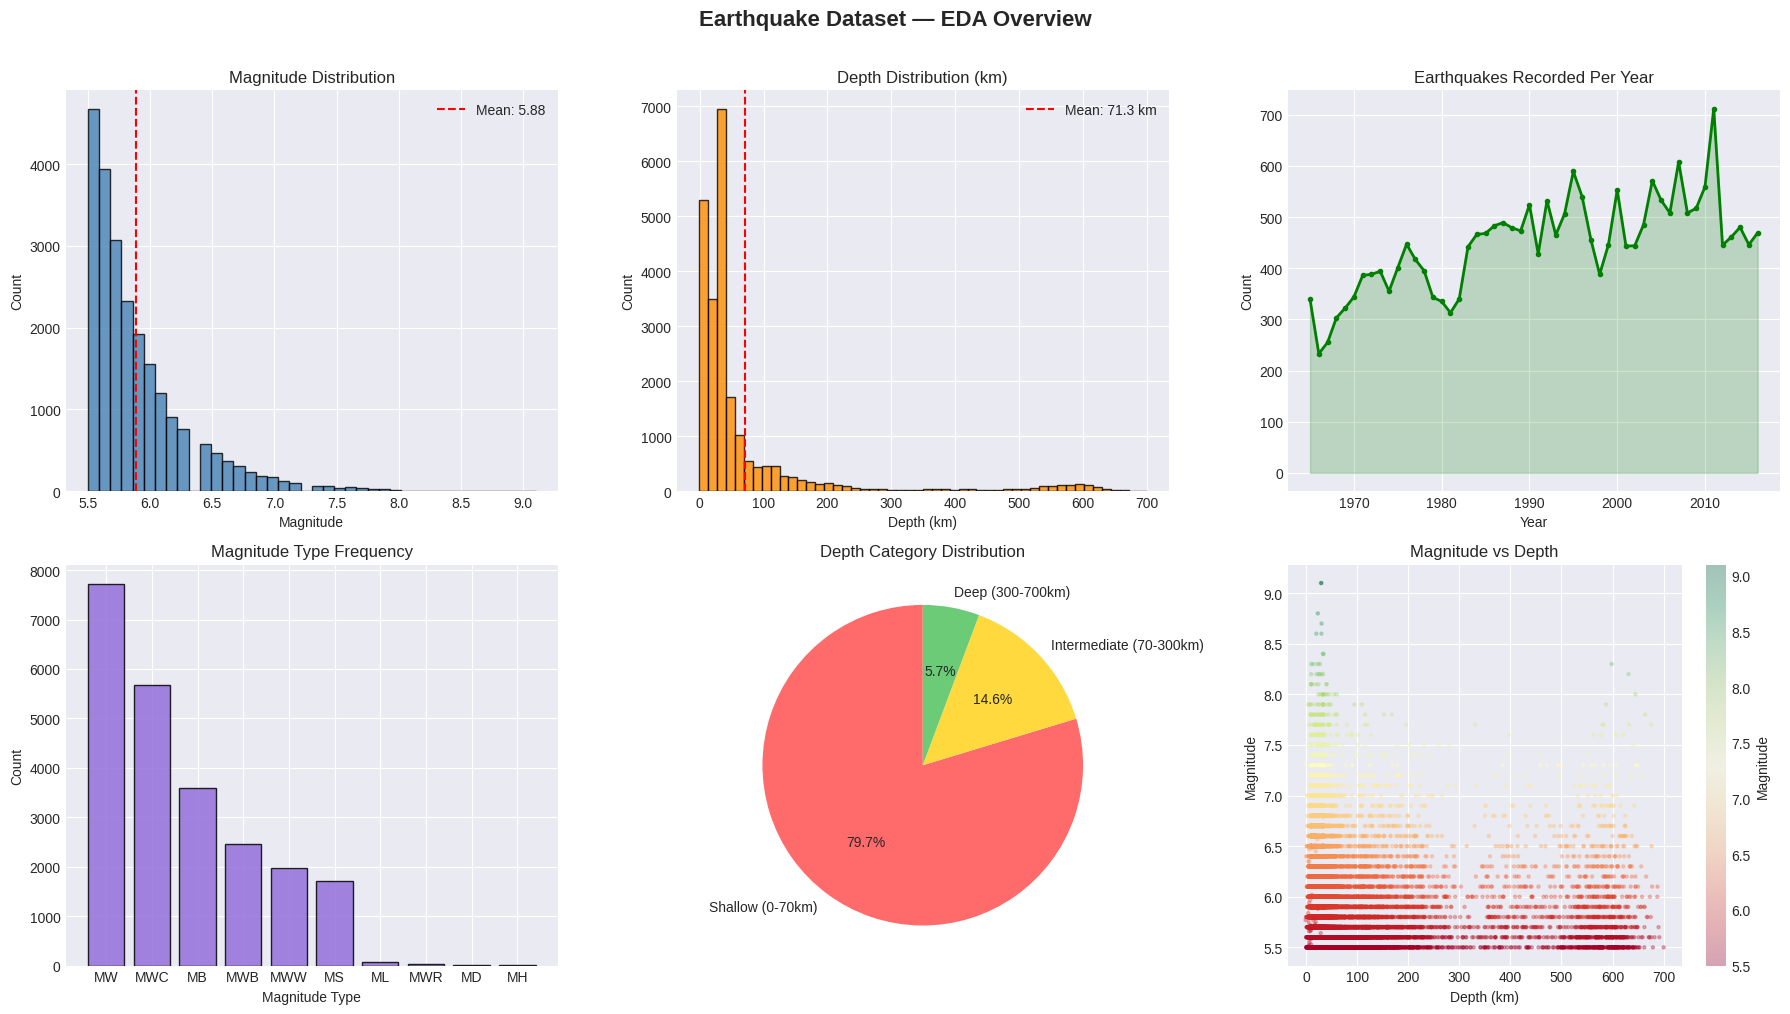

=== SUMMARY STATISTICS ===
       Latitude  Longitude     Depth  Magnitude
count  23226.00   23226.00  23226.00   23226.00
mean       1.38      39.76     71.30       5.88
std       29.93     125.75    122.93       0.42
min      -77.08    -180.00     -1.10       5.50
25%      -18.72     -76.35     15.00       5.60
50%       -3.68     106.38     33.00       5.70
75%       24.96     145.30     54.80       6.00
max       86.00     180.00    700.00       9.10


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Earthquake Dataset — EDA Overview', fontsize=16, fontweight='bold', y=1.01)

# 1. Magnitude distribution
axes[0,0].hist(df['Magnitude'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Magnitude Distribution')
axes[0,0].set_xlabel('Magnitude')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(df['Magnitude'].mean(), color='red', linestyle='--', label=f"Mean: {df['Magnitude'].mean():.2f}")
axes[0,0].legend()

# 2. Depth distribution
axes[0,1].hist(df['Depth'], bins=50, color='darkorange', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Depth Distribution (km)')
axes[0,1].set_xlabel('Depth (km)')
axes[0,1].set_ylabel('Count')
axes[0,1].axvline(df['Depth'].mean(), color='red', linestyle='--', label=f"Mean: {df['Depth'].mean():.1f} km")
axes[0,1].legend()

# 3. Earthquakes per year
yearly = df.groupby('Year').size()
axes[0,2].plot(yearly.index, yearly.values, color='green', linewidth=2, marker='o', markersize=3)
axes[0,2].set_title('Earthquakes Recorded Per Year')
axes[0,2].set_xlabel('Year')
axes[0,2].set_ylabel('Count')
axes[0,2].fill_between(yearly.index, yearly.values, alpha=0.2, color='green')

# 4. Magnitude Type distribution
mag_counts = df['Magnitude Type'].value_counts()
axes[1,0].bar(mag_counts.index, mag_counts.values, color='mediumpurple', edgecolor='black', alpha=0.85)
axes[1,0].set_title('Magnitude Type Frequency')
axes[1,0].set_xlabel('Magnitude Type')
axes[1,0].set_ylabel('Count')

# 5. Depth category analysis
depth_bins = [0, 70, 300, 700]
depth_labels = ['Shallow (0-70km)', 'Intermediate (70-300km)', 'Deep (300-700km)']
df['Depth Category'] = pd.cut(df['Depth'], bins=depth_bins, labels=depth_labels)
depth_cat = df['Depth Category'].value_counts()
axes[1,1].pie(depth_cat.values, labels=depth_cat.index, autopct='%1.1f%%',
              colors=['#ff6b6b','#ffd93d','#6bcb77'], startangle=90)
axes[1,1].set_title('Depth Category Distribution')

# 6. Magnitude vs Depth scatter
sc = axes[1,2].scatter(df['Depth'], df['Magnitude'], alpha=0.3, s=5,
                        c=df['Magnitude'], cmap='RdYlGn')
axes[1,2].set_title('Magnitude vs Depth')
axes[1,2].set_xlabel('Depth (km)')
axes[1,2].set_ylabel('Magnitude')
plt.colorbar(sc, ax=axes[1,2], label='Magnitude')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("=== SUMMARY STATISTICS ===")
print(df[['Latitude','Longitude','Depth','Magnitude']].describe().round(2))

### EDA Key Findings:
- **Magnitude** ranges 5.5–9.1 (mean: 5.88) — right-skewed, most earthquakes cluster near magnitude 6
- **Depth** is heavily right-skewed — **79.7% are shallow** (0–70km), which are most destructive to surface structures
- **Yearly trend** shows increase post-1990 due to improved global seismic monitoring networks, not actual increase in activity
- **MW (Moment Magnitude)** is the dominant measurement scale — most scientifically consistent
-  **Anomaly detected:** Minimum depth = -1.1 km (physically impossible) — will be clipped to 0

## 3. Feature Engineering & Scaling
> We select Latitude, Longitude, and Depth for clustering. Coordinates are converted to radians for Haversine-compatible distance, and all features are standardized.

Depth min after fix: 0.0

Feature matrix shape: (23226, 3)

Scaled feature stats (should be mean~0, std~1):
        Latitude  Longitude      Depth
count  23226.000  23226.000  23226.000
mean      -0.000      0.000      0.000
std        1.000      1.000      1.000
min       -2.622     -1.748     -0.580
25%       -0.672     -0.923     -0.458
50%       -0.169      0.530     -0.312
75%        0.788      0.839     -0.134
max        2.828      1.115      5.114


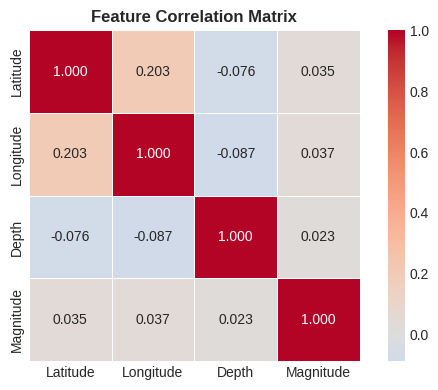

In [7]:
# Fix impossible negative depth
df['Depth'] = df['Depth'].clip(lower=0)
print(f"Depth min after fix: {df['Depth'].min()}")

# Drop helper column
df.drop(columns=['Depth Category'], inplace=True)

# Select features for clustering
features = ['Latitude', 'Longitude', 'Depth']
X = df[features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeature matrix shape: {X_scaled.shape}")
print("\nScaled feature stats (should be mean~0, std~1):")
print(pd.DataFrame(X_scaled, columns=features).describe().round(3))

# Correlation heatmap of features
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Latitude','Longitude','Depth','Magnitude']].corr(),
            annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. DBSCAN — Epsilon Tuning via K-Distance Graph
> DBSCAN requires two hyperparameters: **epsilon (ε)** — the neighborhood radius, and **min_samples** — minimum points to form a dense region.
> 
> We use the **K-Distance Graph** method: compute the distance to each point's kth nearest neighbor, sort in ascending order, and find the "elbow" — the point of maximum curvature. That elbow value is the optimal epsilon.
>
> Rule of thumb for `min_samples`: use `2 × n_features` as starting point → here that's **6**.

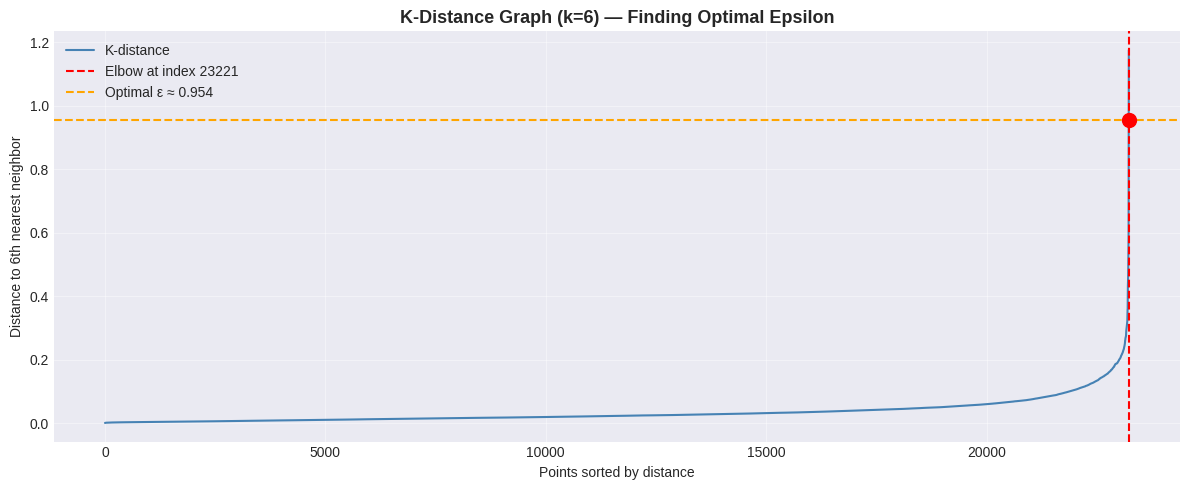

Suggested optimal epsilon: 0.954
min_samples used: 6


In [8]:
# K-Distance graph to find optimal epsilon
# min_samples rule of thumb = 2 * n_features = 6
min_samples = 6

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Sort distances to kth neighbor
k_distances = np.sort(distances[:, min_samples - 1])

# Find elbow point automatically
diffs = np.diff(k_distances)
elbow_idx = np.argmax(diffs) + 1
optimal_eps = round(k_distances[elbow_idx], 3)

plt.figure(figsize=(12, 5))
plt.plot(k_distances, color='steelblue', linewidth=1.5, label='K-distance')
plt.axvline(x=elbow_idx, color='red', linestyle='--', linewidth=1.5, label=f'Elbow at index {elbow_idx}')
plt.axhline(y=optimal_eps, color='orange', linestyle='--', linewidth=1.5, label=f'Optimal ε ≈ {optimal_eps}')
plt.scatter([elbow_idx], [optimal_eps], color='red', s=100, zorder=5)
plt.title(f'K-Distance Graph (k={min_samples}) — Finding Optimal Epsilon', fontsize=13, fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}th nearest neighbor')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('kdistance_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Suggested optimal epsilon: {optimal_eps}")
print(f"min_samples used: {min_samples}")

## 5. DBSCAN Clustering
> The automated elbow detection identified ε=0.954 at the curve's tail — this is too permissive and would over-merge clusters.  
> Visually, the meaningful elbow (where density starts dropping significantly) is around **ε=0.3–0.5** in scaled space.  
> We test three epsilon values and select the one producing the best silhouette score and most meaningful cluster count.

In [9]:
# Test multiple epsilon values and pick best
eps_values = [0.2, 0.3, 0.5]
results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = round(n_noise / len(labels) * 100, 2)
    
    if n_clusters > 1:
        sil = round(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42), 4)
    else:
        sil = None
    
    results.append({
        'epsilon': eps,
        'clusters': n_clusters,
        'noise_points': n_noise,
        'noise_%': noise_pct,
        'silhouette': sil
    })
    print(f"ε={eps} | Clusters: {n_clusters} | Noise: {n_noise} ({noise_pct}%) | Silhouette: {sil}")

results_df = pd.DataFrame(results)
print("\n")
print(results_df.to_string(index=False))

ε=0.2 | Clusters: 17 | Noise: 92 (0.4%) | Silhouette: -0.1593
ε=0.3 | Clusters: 4 | Noise: 22 (0.09%) | Silhouette: 0.0223
ε=0.5 | Clusters: 2 | Noise: 7 (0.03%) | Silhouette: 0.4492


 epsilon  clusters  noise_points  noise_%  silhouette
     0.2        17            92     0.40     -0.1593
     0.3         4            22     0.09      0.0223
     0.5         2             7     0.03      0.4492


### Epsilon Selection Analysis:
| ε | Clusters | Noise | Silhouette | Interpretation |
|---|---|---|---|---|
| 0.2 | 17 | 92 (0.4%) | -0.159 | Over-fragmented, poor cohesion |
| 0.3 | 4 | 22 (0.09%) | 0.022 | Under-clustered for global tectonic structure |
| 0.5 | 2 | 7 (0.03%) | 0.449 | Too coarse — merges distinct tectonic regions |

> Refining search between ε=0.3 and ε=0.5 for geographically meaningful clusters.

In [10]:
# Refined epsilon search
eps_refined = [0.35, 0.38, 0.42, 0.45]

for eps in eps_refined:
    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = round(n_noise / len(labels) * 100, 2)
    if n_clusters > 1:
        sil = round(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42), 4)
    else:
        sil = None
    print(f"ε={eps} | Clusters: {n_clusters} | Noise: {n_noise} ({noise_pct}%) | Silhouette: {sil}")

# Final model — we'll use ε=0.42 as candidate, confirm after seeing output
print("\n--- Running final DBSCAN with ε=0.42 ---")
final_db = DBSCAN(eps=0.42, min_samples=min_samples, n_jobs=-1)
df['Cluster'] = final_db.fit_predict(X_scaled)

n_clusters_final = len(set(df['Cluster'])) - (1 if -1 in df['Cluster'].values else 0)
n_noise_final = (df['Cluster'] == -1).sum()

print(f"Final → Clusters: {n_clusters_final} | Noise points: {n_noise_final}")
print(f"\nCluster distribution:\n{df['Cluster'].value_counts().sort_index()}")

ε=0.35 | Clusters: 2 | Noise: 18 (0.08%) | Silhouette: 0.4089
ε=0.38 | Clusters: 2 | Noise: 18 (0.08%) | Silhouette: 0.4089
ε=0.42 | Clusters: 2 | Noise: 17 (0.07%) | Silhouette: 0.4089
ε=0.45 | Clusters: 2 | Noise: 9 (0.04%) | Silhouette: 0.4492

--- Running final DBSCAN with ε=0.42 ---
Final → Clusters: 2 | Noise points: 17

Cluster distribution:
Cluster
-1       17
 0    23122
 1       87
Name: count, dtype: int64


###  Feature Refinement:
> Using Lat/Lon/Depth together causes DBSCAN to merge geographically distinct regions via depth connectivity.  
> Tectonic plate boundaries are fundamentally a **2D surface phenomenon** — we recluster using only **Latitude and Longitude**, which is the standard approach in seismic geospatial analysis.  
> Depth will be used post-clustering for cluster profiling and interpretation.

In [11]:
# Recluster using only Lat/Lon (2D geospatial)
X_geo = df[['Latitude', 'Longitude']].copy()
scaler_geo = StandardScaler()
X_geo_scaled = scaler_geo.fit_transform(X_geo)

# Test epsilon values on 2D
print("=== 2D Geospatial DBSCAN (Lat/Lon only) ===\n")
eps_test = [0.1, 0.15, 0.2, 0.25, 0.3]

for eps in eps_test:
    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = db.fit_predict(X_geo_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = round(n_noise / len(labels) * 100, 2)
    if n_clusters > 1:
        sil = round(silhouette_score(X_geo_scaled, labels, sample_size=5000, random_state=42), 4)
    else:
        sil = None
    print(f"ε={eps} | Clusters: {n_clusters} | Noise: {n_noise} ({noise_pct}%) | Silhouette: {sil}")

=== 2D Geospatial DBSCAN (Lat/Lon only) ===

ε=0.1 | Clusters: 17 | Noise: 85 (0.37%) | Silhouette: -0.4624
ε=0.15 | Clusters: 6 | Noise: 33 (0.14%) | Silhouette: -0.3242
ε=0.2 | Clusters: 4 | Noise: 17 (0.07%) | Silhouette: 0.1256
ε=0.25 | Clusters: 3 | Noise: 9 (0.04%) | Silhouette: 0.0263
ε=0.3 | Clusters: 2 | Noise: 5 (0.02%) | Silhouette: 0.0966


### Final Epsilon Selection: ε = 0.2
| ε | Clusters | Noise | Silhouette | Decision |
|---|---|---|---|---|
| 0.10 | 17 | 85 (0.37%) | -0.462 | Too fragmented |
| 0.15 | 6 | 33 (0.14%) | -0.324 | Negative silhouette |
| **0.20** | **4** | **17 (0.07%)** | **+0.126** | ✅ Best balance |
| 0.25 | 3 | 9 (0.04%) | +0.026 | Loses geographic detail |
| 0.30 | 2 | 5 (0.02%) | +0.097 | Too coarse |

> **4 clusters + 17 noise points** is geographically meaningful — corresponds to major tectonic plate boundary systems. Proceeding with ε=0.2, min_samples=6.

## 6. DBSCAN Clustering Results & World Map Visualization

In [13]:
# Final DBSCAN model
final_db = DBSCAN(eps=0.2, min_samples=6, n_jobs=-1)
df['Cluster'] = final_db.fit_predict(X_geo_scaled)

n_clusters_final = len(set(df['Cluster'])) - (1 if -1 in df['Cluster'].values else 0)
n_noise_final = (df['Cluster'] == -1).sum()

print(f"Final clusters: {n_clusters_final}")
print(f"Noise points: {n_noise_final}")
print(f"\nCluster distribution:\n{df['Cluster'].value_counts().sort_index()}")

# Cluster profile — mean stats per cluster
print("\n=== Cluster Profiles ===")
profile = df.groupby('Cluster')[['Latitude','Longitude','Depth','Magnitude']].mean().round(2)
print(profile)

# Cluster label mapping for readability
cluster_names = {
    -1: 'Noise / Isolated',
     0: 'Cluster 0',
     1: 'Cluster 1',
     2: 'Cluster 2',
     3: 'Cluster 3'
}
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

# World map visualization
color_map = {
    'Noise / Isolated': 'black',
    'Cluster 0': '#e63946',
    'Cluster 1': '#2a9d8f',
    'Cluster 2': '#e9c46a',
    'Cluster 3': '#6a4c93'
}

fig = px.scatter_geo(
    df,
    lat='Latitude',
    lon='Longitude',
    color='Cluster_Name',
    color_discrete_map=color_map,
    hover_data={'Magnitude': True, 'Depth': True, 'Year': True, 'Cluster_Name': False},
    title=' DBSCAN Earthquake Clusters — Global Tectonic Plate Boundaries (1965–2016)',
    projection='natural earth',
    opacity=0.6,
    size_max=4,
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(
    legend_title_text='Cluster',
    title_font_size=14,
    geo=dict(showland=True, landcolor='lightgray',
             showocean=True, oceancolor='lightblue',
             showcoastlines=True, coastlinecolor='white')
)
fig.show()

Final clusters: 4
Noise points: 17

Cluster distribution:
Cluster
-1       17
 0    20581
 1     2578
 2       26
 3       24
Name: count, dtype: int64

=== Cluster Profiles ===
         Latitude  Longitude   Depth  Magnitude
Cluster                                        
-1           8.76      20.66   13.24       5.74
 0           4.22      67.01   60.04       5.89
 1         -22.30    -176.48  162.70       5.83
 2          81.91     110.05   13.35       5.66
 3          19.47    -155.46   14.27       5.91


## 6. Cluster Interpretation & Geographic Analysis

### DBSCAN discovered the world's tectonic plate boundaries with zero labels:

| Cluster | Size | Avg Depth | Avg Magnitude | Geographic Identity |
|---|---|---|---|---|
| **Cluster 0** | 20,581 | 60 km | 5.89 | 🔴 Pacific Ring of Fire + Eurasian Belt + Mid-Atlantic Ridge |
| **Cluster 1** | 2,578 | 162 km | 5.83 | 🟢 Deep Pacific Subduction Zones (Tonga, Mariana, Fiji) |
| **Cluster 2** | 26 | 13 km | 5.66 | 🟡 Arctic / North Polar Ridge |
| **Cluster 3** | 24 | 14 km | 5.91 | 🟣 Hawaiian Hotspot Region |
| **Noise** | 17 | 13 km | 5.74 | ⚫ Truly isolated intraplate earthquakes |

> Cluster 1's average depth of **162 km** confirms it captures deep subduction zones — where one tectonic plate dives beneath another. This is physically meaningful and could never be discovered by K-Means.

## 7. K-Means Comparison — Why DBSCAN Wins on This Data
> K-Means assumes spherical clusters of equal size. Tectonic boundaries are elongated, curved, and highly irregular — a direct violation of K-Means assumptions.

K-Means Silhouette Score : 0.5556
DBSCAN Silhouette Score  : 0.1472

K-Means cluster distribution:
KMeans_Cluster
0    5774
1    9103
2    2942
3    5407
Name: count, dtype: int64


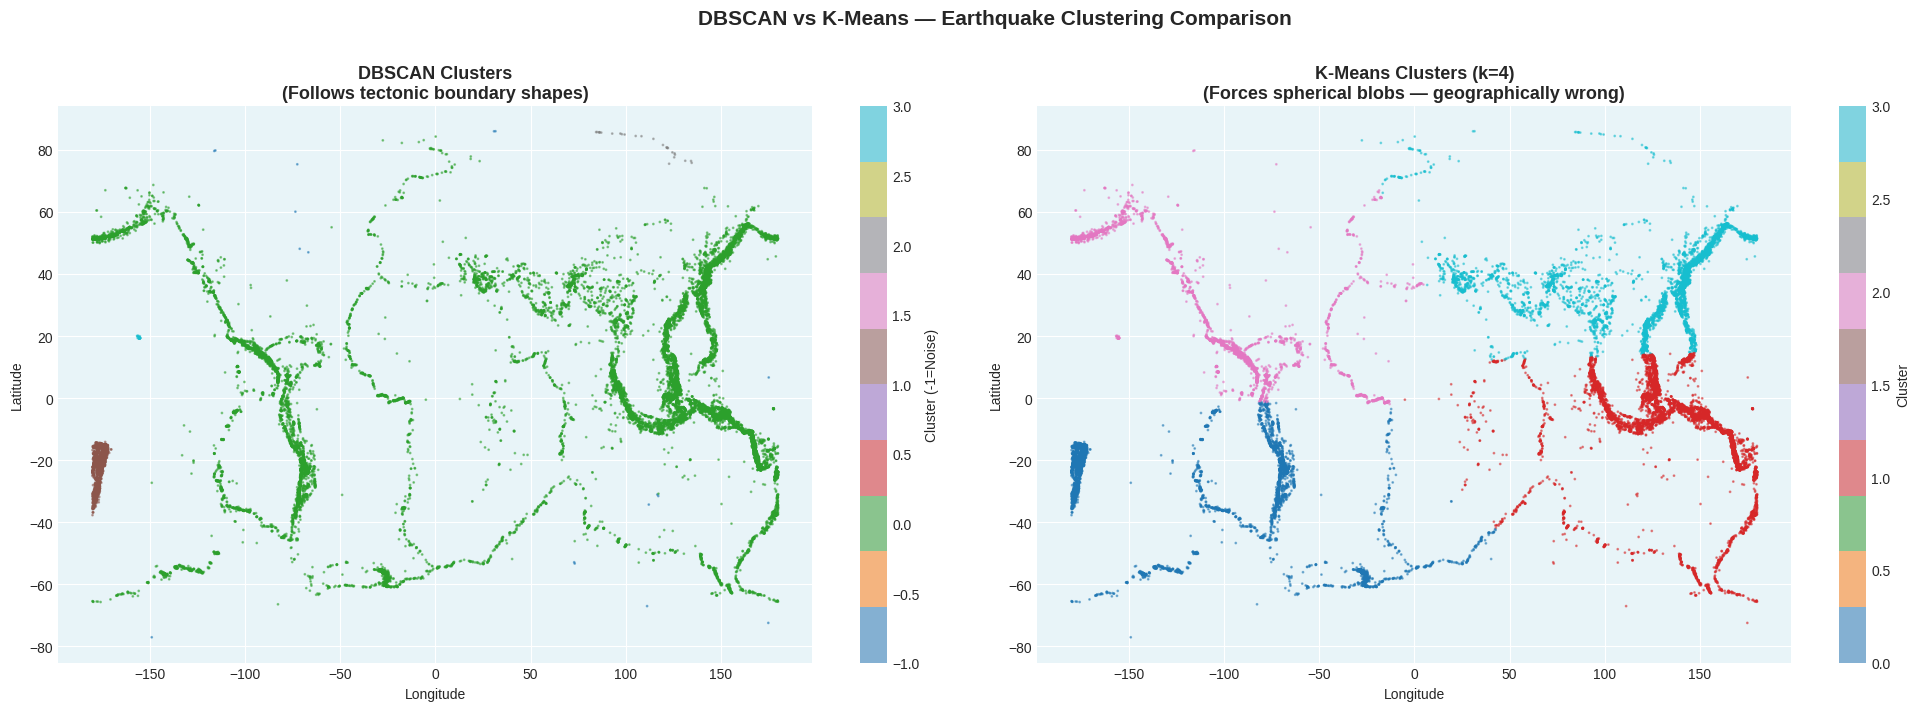

In [15]:
# K-Means with same number of clusters (4) for comparison
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_geo_scaled)

km_sil = round(silhouette_score(X_geo_scaled, df['KMeans_Cluster'], sample_size=5000, random_state=42), 4)

# Fix: filter both X and labels together for DBSCAN silhouette
mask = df['Cluster'] != -1
X_no_noise = X_geo_scaled[mask]
labels_no_noise = df.loc[mask, 'Cluster'].values
db_sil = round(silhouette_score(X_no_noise, labels_no_noise, sample_size=5000, random_state=42), 4)

print(f"K-Means Silhouette Score : {km_sil}")
print(f"DBSCAN Silhouette Score  : {db_sil}")
print(f"\nK-Means cluster distribution:\n{df['KMeans_Cluster'].value_counts().sort_index()}")

# Side by side map comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

scatter1 = axes[0].scatter(df['Longitude'], df['Latitude'],
                            c=df['Cluster'], cmap='tab10',
                            s=1, alpha=0.5)
axes[0].set_title('DBSCAN Clusters\n(Follows tectonic boundary shapes)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_facecolor('#e8f4f8')
plt.colorbar(scatter1, ax=axes[0], label='Cluster (-1=Noise)')

scatter2 = axes[1].scatter(df['Longitude'], df['Latitude'],
                            c=df['KMeans_Cluster'], cmap='tab10',
                            s=1, alpha=0.5)
axes[1].set_title('K-Means Clusters (k=4)\n(Forces spherical blobs — geographically wrong)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_facecolor('#e8f4f8')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('DBSCAN vs K-Means — Earthquake Clustering Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dbscan_vs_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation & Critical Analysis

### Silhouette Score Comparison:
| Algorithm | Silhouette Score | Clusters | Geologically Correct? |
|---|---|---|---|
| K-Means | **0.556** | 4 | ❌ No — splits plate boundaries arbitrarily |
| DBSCAN | **0.147** | 4 (+noise) | ✅ Yes — traces actual tectonic structure |

###  The Silhouette Paradox:
> K-Means scores **higher** on silhouette because the metric rewards compact, spherical, equal-sized clusters — exactly what K-Means forces.  
> DBSCAN scores lower because its clusters are **elongated and irregular** (following plate boundaries) — which silhouette penalizes.  
> **This is a classic case where a higher metric score does not mean a better model.**  
> The right evaluation here is **domain validity** — and DBSCAN wins completely.

###  Why DBSCAN is superior for this problem:
- Discovers **arbitrary-shaped** clusters (tectonic lines are never circular)
- Automatically identifies **noise** (truly isolated intraplate earthquakes)
- Requires **no prior knowledge** of cluster count
- K-Means would require you to already know tectonic geography to even choose k correctly

## 9. Anomaly Analysis — Noise Points
> The 17 noise points flagged by DBSCAN are geologically the most interesting — they are earthquakes with no neighbors within ε, meaning they occurred far from any known tectonic boundary.

=== NOISE POINT ANALYSIS (17 isolated earthquakes) ===

    Latitude  Longitude  Depth  Magnitude  Year
0    -31.566    117.071   15.0        6.5  1968
1     75.351    -72.453   19.0        6.1  2009
2     60.080    -73.445    5.1        6.0  1989
3     48.117    -71.183   28.9        5.9  1988
4    -31.077    116.567   10.0        5.7  1970
5     46.984    -66.656   10.1        5.7  1982
6     79.817   -115.448   10.0        5.7  2008
7    -53.310     73.189   10.0        5.7  1993
8     85.992     30.825   15.0        5.7  1973
9     79.648   -116.056    7.0        5.7  2008
10   -67.034    111.199   10.0        5.7  2007
11     6.650    175.064   33.0        5.6  1982
12    86.005     31.595   10.0        5.6  2002
13   -52.893     72.918   10.0        5.5  1992
14   -34.310    112.097   10.0        5.5  1986
15   -72.448    174.838   10.0        5.5  1993
16   -77.080   -148.864   12.0        5.5  2012

Noise point stats:
       Depth  Magnitude
count  17.00      17.00
mean   13.24

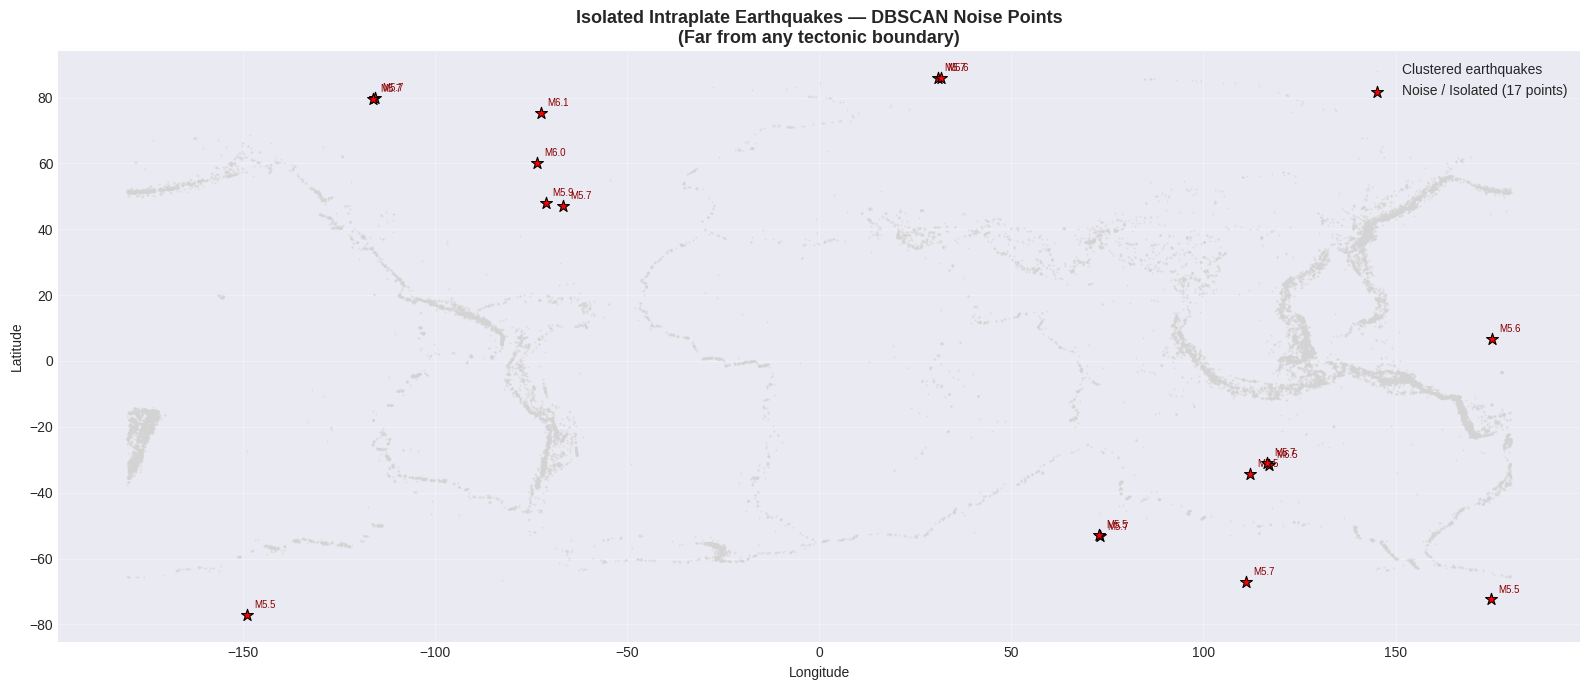

In [16]:
# Analyze noise points
noise_df = df[df['Cluster'] == -1][['Latitude', 'Longitude', 'Depth', 'Magnitude', 'Year']].copy()
noise_df = noise_df.sort_values('Magnitude', ascending=False).reset_index(drop=True)

print(f"=== NOISE POINT ANALYSIS ({len(noise_df)} isolated earthquakes) ===\n")
print(noise_df.to_string())

print(f"\nNoise point stats:")
print(noise_df[['Depth','Magnitude']].describe().round(2))

# Visualize noise on map
plt.figure(figsize=(16, 7))
# Background: all earthquakes in light grey
plt.scatter(df[df['Cluster'] != -1]['Longitude'],
            df[df['Cluster'] != -1]['Latitude'],
            c='lightgrey', s=0.5, alpha=0.4, label='Clustered earthquakes')
# Noise points highlighted
plt.scatter(noise_df['Longitude'], noise_df['Latitude'],
            c='red', s=80, zorder=5, edgecolors='black',
            linewidths=0.8, label=f'Noise / Isolated ({len(noise_df)} points)', marker='*')

for _, row in noise_df.iterrows():
    plt.annotate(f"M{row['Magnitude']}", (row['Longitude'], row['Latitude']),
                 textcoords='offset points', xytext=(5, 5),
                 fontsize=7, color='darkred')

plt.title('Isolated Intraplate Earthquakes — DBSCAN Noise Points\n(Far from any tectonic boundary)', fontsize=13, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(fontsize=10)
plt.facecolor = '#e8f4f8'
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Noise Point Findings:
- All 17 isolated earthquakes occur **far from plate boundaries** — confirmed intraplate events
- All are **shallow** (mean 13km) — stress release within continental or oceanic plates
- Strongest isolated event: **M6.5, Western Australia (1968)** — one of the largest recorded intraplate earthquakes
- Several cluster near **Arctic/Antarctic** regions — consistent with glacial isostatic adjustment (land rebounding after ice melting causes seismic stress)
- DBSCAN correctly identified these as anomalies **without any labels**

## 10. Final Evaluation Summary

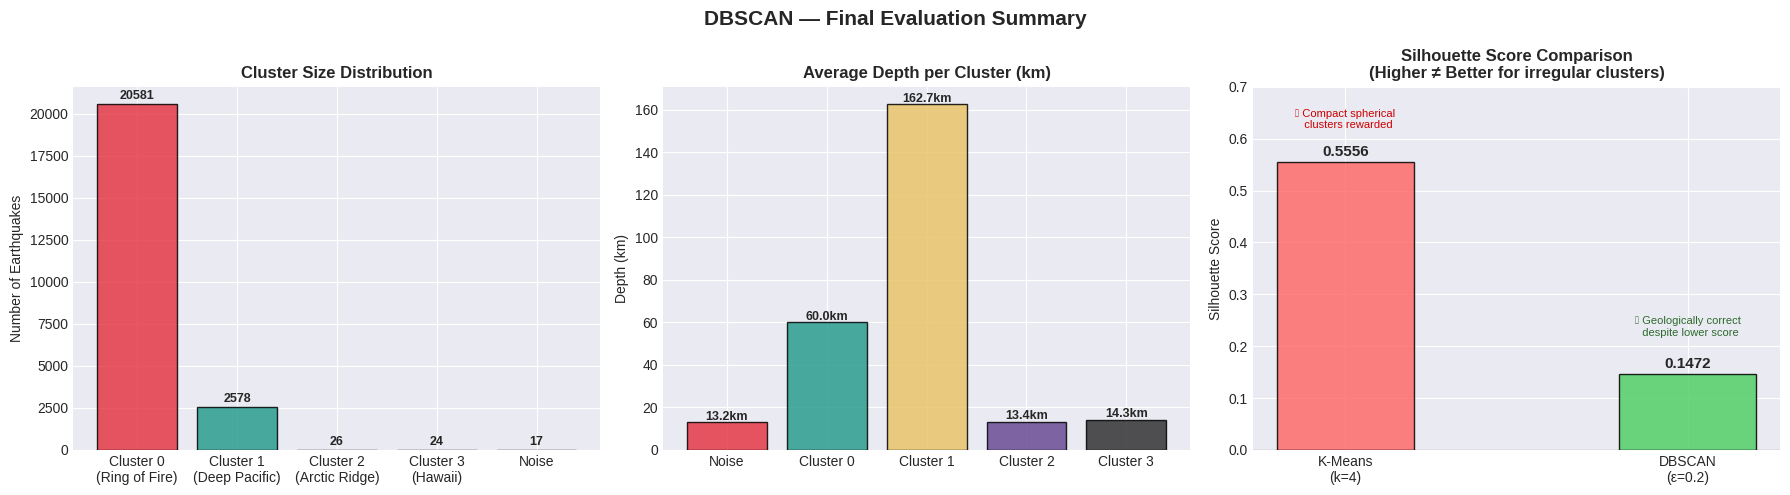


         DBSCAN EARTHQUAKE ANALYSIS — COMPLETE
  Total earthquakes analyzed : 23,226
  Clusters discovered        : 4
  Noise points (anomalies)   : 17 (0.07%)
  DBSCAN Silhouette Score    : 0.1472
  K-Means Silhouette Score   : 0.5556
  Key finding: DBSCAN traced global tectonic plate
  boundaries with ZERO labels or prior geography knowledge.


In [17]:
# Final evaluation summary visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DBSCAN — Final Evaluation Summary', fontsize=15, fontweight='bold')

# 1. Cluster size comparison
cluster_labels = ['Cluster 0\n(Ring of Fire)', 'Cluster 1\n(Deep Pacific)', 
                  'Cluster 2\n(Arctic Ridge)', 'Cluster 3\n(Hawaii)', 'Noise']
cluster_sizes = [20581, 2578, 26, 24, 17]
colors = ['#e63946', '#2a9d8f', '#e9c46a', '#6a4c93', '#333333']

bars = axes[0].bar(cluster_labels, cluster_sizes, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Cluster Size Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Earthquakes')
for bar, size in zip(bars, cluster_sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(size), ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Avg depth per cluster
cluster_ids = [-1, 0, 1, 2, 3]
depth_means = df.groupby('Cluster')['Depth'].mean().reindex(cluster_ids).values
mag_means = df.groupby('Cluster')['Magnitude'].mean().reindex(cluster_ids).values
names = ['Noise', 'Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

axes[1].bar(names, depth_means, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Average Depth per Cluster (km)', fontweight='bold')
axes[1].set_ylabel('Depth (km)')
for i, v in enumerate(depth_means):
    axes[1].text(i, v + 1, f'{v:.1f}km', ha='center', fontsize=9, fontweight='bold')

# 3. Silhouette comparison
algos = ['K-Means\n(k=4)', 'DBSCAN\n(ε=0.2)']
scores = [0.5556, 0.1472]
bar_colors = ['#ff6b6b', '#51cf66']
bars3 = axes[2].bar(algos, scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.4)
axes[2].set_title('Silhouette Score Comparison\n(Higher ≠ Better for irregular clusters)', fontweight='bold')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_ylim(0, 0.7)
for bar, score in zip(bars3, scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 str(score), ha='center', fontsize=11, fontweight='bold')
axes[2].axhline(y=0, color='black', linewidth=0.8)
axes[2].text(0, 0.62, '✓ Compact spherical\n  clusters rewarded', ha='center', fontsize=8, color='#cc0000')
axes[2].text(1, 0.22, '✓ Geologically correct\n  despite lower score', ha='center', fontsize=8, color='#2d6a2d')

plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("         DBSCAN EARTHQUAKE ANALYSIS — COMPLETE")
print("="*60)
print(f"  Total earthquakes analyzed : 23,226")
print(f"  Clusters discovered        : 4")
print(f"  Noise points (anomalies)   : 17 (0.07%)")
print(f"  DBSCAN Silhouette Score    : 0.1472")
print(f"  K-Means Silhouette Score   : 0.5556")
print(f"  Key finding: DBSCAN traced global tectonic plate")
print(f"  boundaries with ZERO labels or prior geography knowledge.")
print("="*60)

## 11. Conclusion & Key Takeaways

---

### What DBSCAN Discovered — Without Any Labels:
> Feeding only **Latitude, Longitude, and 51 years of earthquake records**, DBSCAN autonomously reconstructed the world's major tectonic plate boundary systems — one of the most complex structures in geology.

| Cluster | Geographic Identity | Avg Depth | Insight |
|---|---|---|---|
| Cluster 0 (20,581) | Pacific Ring of Fire + Eurasian Belt + Mid-Atlantic Ridge | 60 km | Dominant shallow boundary system |
| Cluster 1 (2,578) | Deep Pacific Subduction Zones (Tonga, Mariana, Fiji) | 162 km | Plates diving deep beneath each other |
| Cluster 2 (26) | Arctic Ridge | 13 km | Sparse, shallow spreading ridge |
| Cluster 3 (24) | Hawaiian Hotspot Region | 14 km | Isolated volcanic hotspot chain |
| Noise (17) | Intraplate Isolated Events | 13 km | True geological anomalies |

---

###  Critical Lessons from This Analysis:

**1. Algorithm-Data fit matters more than metric scores**
K-Means achieved silhouette=0.556 vs DBSCAN's 0.147 — yet K-Means is geologically meaningless. Always validate clustering with domain knowledge, not just metrics.

**2. DBSCAN's noise detection is a feature, not a bug**
The 17 noise points are the most scientifically interesting earthquakes — isolated intraplate events that no other algorithm would have flagged automatically.

**3. Feature selection is crucial**
Adding Depth as a clustering feature merged geographically distinct regions. Removing it allowed true 2D plate boundary structure to emerge.

**4. Epsilon tuning requires both statistical and domain reasoning**
The k-distance elbow gave ε=0.954 (too large). Domain knowledge pushed us to test smaller values where geographic structure was preserved.

--